In [200]:
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import accuracy_score, classification_report, silhouette_score
from sklearn.decomposition import PCA

In [201]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("imakash3011/customer-personality-analysis")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'customer-personality-analysis' dataset.
Path to dataset files: /kaggle/input/customer-personality-analysis


In [202]:
import os

# Download dataset
path = kagglehub.dataset_download(
    "imakash3011/customer-personality-analysis"
)

print("Dataset Path:", path)

# Read file correctly
csv_path = os.path.join(path, "marketing_campaign.csv")

df = pd.read_csv(csv_path, sep="\t")

print(df.head())
print(df.shape)
print(df.columns)

Using Colab cache for faster access to the 'customer-personality-analysis' dataset.
Dataset Path: /kaggle/input/customer-personality-analysis
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  04-09-2012       58       635  ...                  7             0   
1  08-03-2014       38        11  ...                  5             0   
2  21-08-2013       26       426  ...                  4             0   
3  10-02-2014       26        11  ...                  6             0   
4  19-01-2014      

In [203]:
df.isna().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [204]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [205]:
df.describe(include='object')

,Education,Marital_Status,Dt_Customer
count,2240,2240,2240
unique,5,8,663
top,Graduation,Married,31-08-2012
freq,1127,864,12


In [206]:
df.duplicated().sum()

np.int64(0)

In [207]:
df['Income'].fillna(df['Income'].median(), inplace=True)

print(df['Income'].isnull().sum())

0


/tmp/ipykernel_2187/955229772.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Income'].fillna(df['Income'].median(), inplace=True)


In [208]:
from datetime import datetime

current_year = datetime.now().year

df['Age'] = current_year - df['Year_Birth']

In [209]:
df['Total_Spending'] = (
    df['MntWines']
    + df['MntFruits']
    + df['MntMeatProducts']
    + df['MntFishProducts']
    + df['MntSweetProducts']
    + df['MntGoldProds']
)

In [210]:
df['Children'] = df['Kidhome'] + df['Teenhome']

In [211]:
df['Total_Purchases'] = (
    df['NumWebPurchases']
    + df['NumCatalogPurchases']
    + df['NumStorePurchases']
)

In [212]:
df['Dt_Customer'] = pd.to_datetime(
    df['Dt_Customer'],
    format='%d-%m-%Y'
)

df['Customer_Days'] = (
    df['Dt_Customer'].max() - df['Dt_Customer']
).dt.days

In [213]:
df.drop(
    columns=[
        'ID',
        'Year_Birth',
        'Dt_Customer',
        'Z_CostContact',
        'Z_Revenue'
    ],
    inplace=True
)

In [214]:
print(df.shape)

df.head()

(2240, 29)


,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Total_Spending,Children,Total_Purchases,Customer_Days
0,Graduation,Single,58138.0,0,0,58,635,88,546,172,...,0,0,0,0,1,69,1617,0,22,663
1,Graduation,Single,46344.0,1,1,38,11,1,6,2,...,0,0,0,0,0,72,27,2,4,113
2,Graduation,Together,71613.0,0,0,26,426,49,127,111,...,0,0,0,0,0,61,776,0,20,312
3,Graduation,Together,26646.0,1,0,26,11,4,20,10,...,0,0,0,0,0,42,53,1,6,139
4,PhD,Married,58293.0,1,0,94,173,43,118,46,...,0,0,0,0,0,45,422,1,14,161


In [215]:
print(df.shape)
print(df.columns)
print("Duplicate Rows:", df.duplicated().sum())

(2240, 29)
Index(['Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome',
       'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Complain', 'Response', 'Age', 'Total_Spending', 'Children',
       'Total_Purchases', 'Customer_Days'],
      dtype='object')
Duplicate Rows: 182


In [216]:
print("Before:", df.shape)

df = df.drop_duplicates()

print("After:", df.shape)

Before: (2240, 29)
After: (2058, 29)


In [217]:
cat_cols = ['Education', 'Marital_Status']

num_cols = [col for col in df.columns
            if col not in cat_cols + ['Response']]

print("Numerical Features:", len(num_cols))
print("Categorical Features:", len(cat_cols))

Numerical Features: 26
Categorical Features: 2


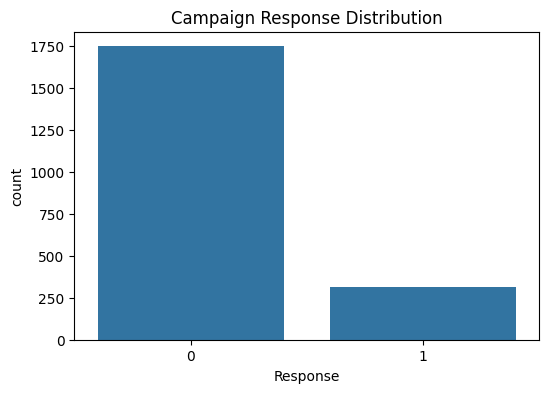

Response
0    84.791059
1    15.208941
Name: proportion, dtype: float64


In [218]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x='Response', data=df)

plt.title("Campaign Response Distribution")
plt.show()

print(df['Response'].value_counts(normalize=True)*100)

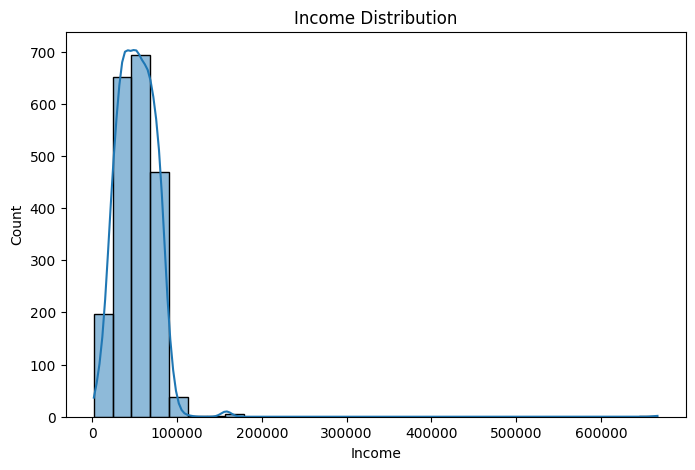

In [219]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Income'],
    kde=True,
    bins=30
)

plt.title("Income Distribution")
plt.show()

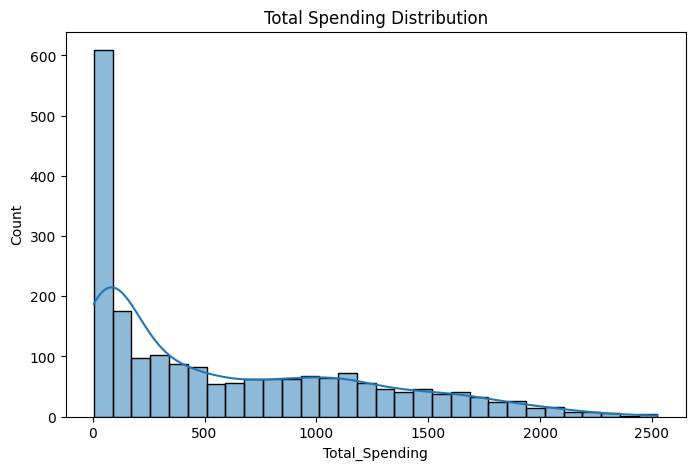

In [220]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Total_Spending'],
    kde=True,
    bins=30
)

plt.title("Total Spending Distribution")
plt.show()

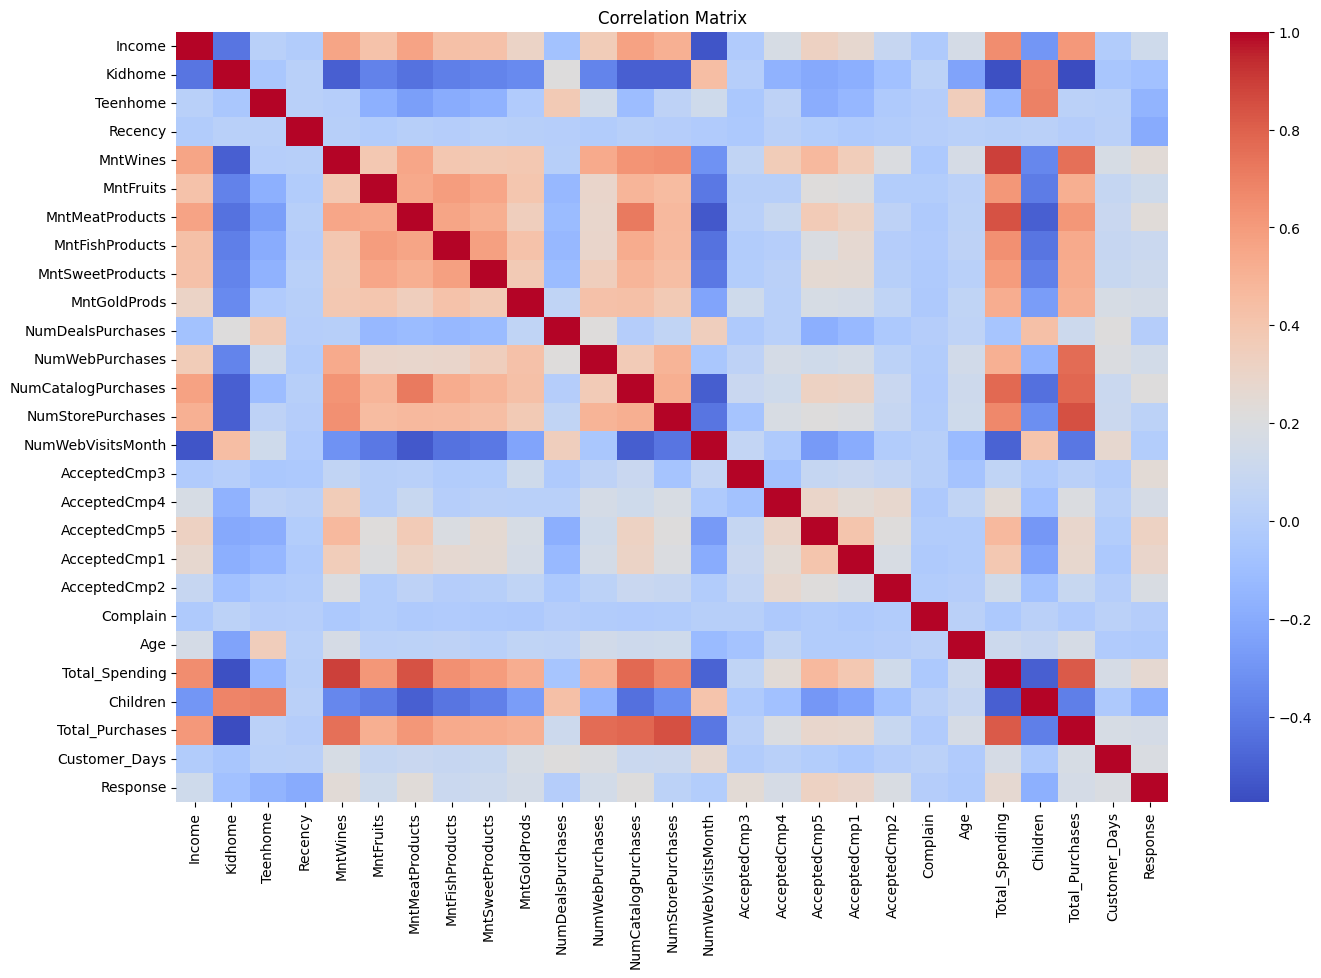

In [221]:
plt.figure(figsize=(16,10))

corr = df[num_cols + ['Response']].corr()

sns.heatmap(
    corr,
    cmap='coolwarm',
    annot=False
)

plt.title("Correlation Matrix")
plt.show()

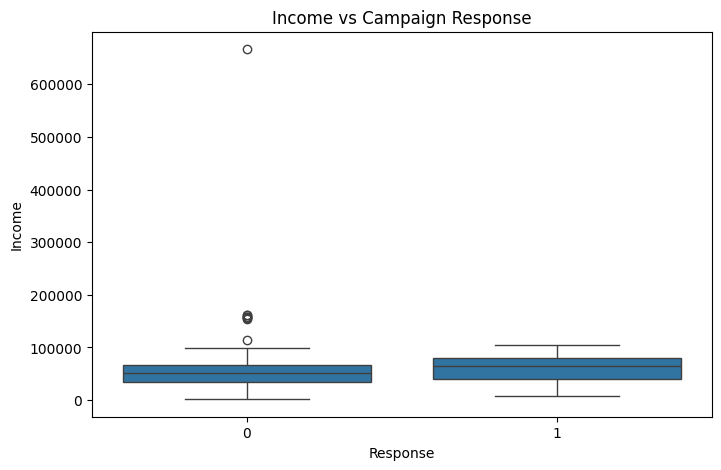

In [222]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Response',
    y='Income',
    data=df
)

plt.title("Income vs Campaign Response")
plt.show()

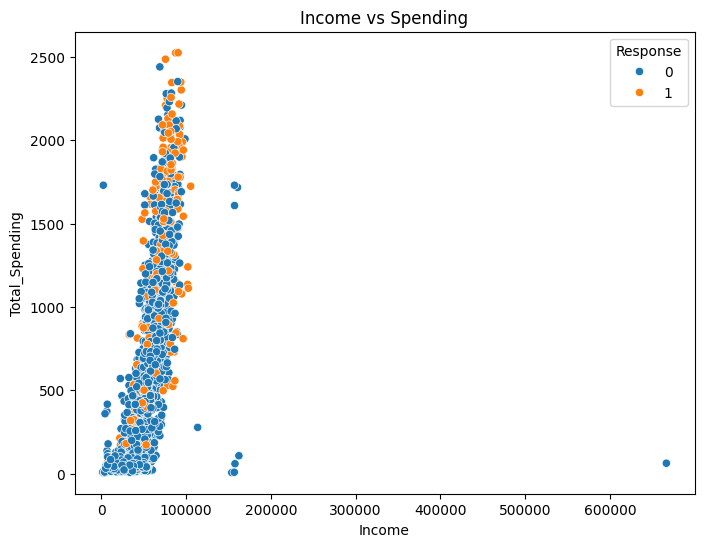

In [223]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Income',
    y='Total_Spending',
    hue='Response'
)

plt.title("Income vs Spending")
plt.show()

In [224]:
def count_outliers(df, columns):

    for col in columns:

        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)

        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        outliers = df[
            (df[col] < lower) |
            (df[col] > upper)
        ].shape[0]

        print(f"{col}: {outliers}")

In [225]:
count_outliers(
    df,
    ['Income','Age','Total_Spending','Total_Purchases']
)

Income: 8
Age: 3
Total_Spending: 3
Total_Purchases: 0


In [226]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import RobustScaler

In [227]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            RobustScaler(),
            num_cols
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            cat_cols
        )
    ]
)

In [228]:
from sklearn.model_selection import train_test_split

X = df.drop('Response', axis=1)

y = df['Response']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1646, 28)
(412, 28)


In [229]:
from sklearn.linear_model import LogisticRegression

log_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=500,
        class_weight='balanced'
    ))
])

In [230]:
log_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', RobustScaler(),
                                                  ['Income', 'Kidhome',
                                                   'Teenhome', 'Recency',
                                                   'MntWines', 'MntFruits',
                                                   'MntMeatProducts',
                                                   'MntFishProducts',
                                                   'MntSweetProducts',
                                                   'MntGoldProds',
                                                   'NumDealsPurchases',
                                                   'NumWebPurchases',
                                                   'NumCatalogPurchases',
                                                   'NumStorePurchases',
                                                   'NumWebVisitsMonth',
                                                   'AcceptedCmp3',
                                                   'AcceptedCmp4',
                                                   'AcceptedCmp5',
                                                   'AcceptedCmp1',
                                                   'AcceptedCmp2', 'Complain',
                                                   'Age', 'Total_Spending',
                                                   'Children',
                                                   'Total_Purchases',
                                                   'Customer_Days']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Education',
                                                   'Marital_Status'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=500))])

In [231]:
y_pred = log_pipeline.predict(X_test)

In [232]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Accuracy:",
      accuracy_score(y_test, y_pred))

print(classification_report(
    y_test,
    y_pred
))

Accuracy: 0.8495145631067961
              precision    recall  f1-score   support

           0       0.97      0.85      0.91       349
           1       0.50      0.86      0.64        63

    accuracy                           0.85       412
   macro avg       0.74      0.85      0.77       412
weighted avg       0.90      0.85      0.86       412



In [233]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    ))
])

dt_pipeline.fit(X_train, y_train)

y_pred_dt = dt_pipeline.predict(X_test)

In [234]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:",
      accuracy_score(y_test, y_pred_dt))

print(classification_report(
    y_test,
    y_pred_dt
))

Accuracy: 0.8737864077669902
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       349
           1       0.69      0.32      0.43        63

    accuracy                           0.87       412
   macro avg       0.79      0.65      0.68       412
weighted avg       0.86      0.87      0.85       412



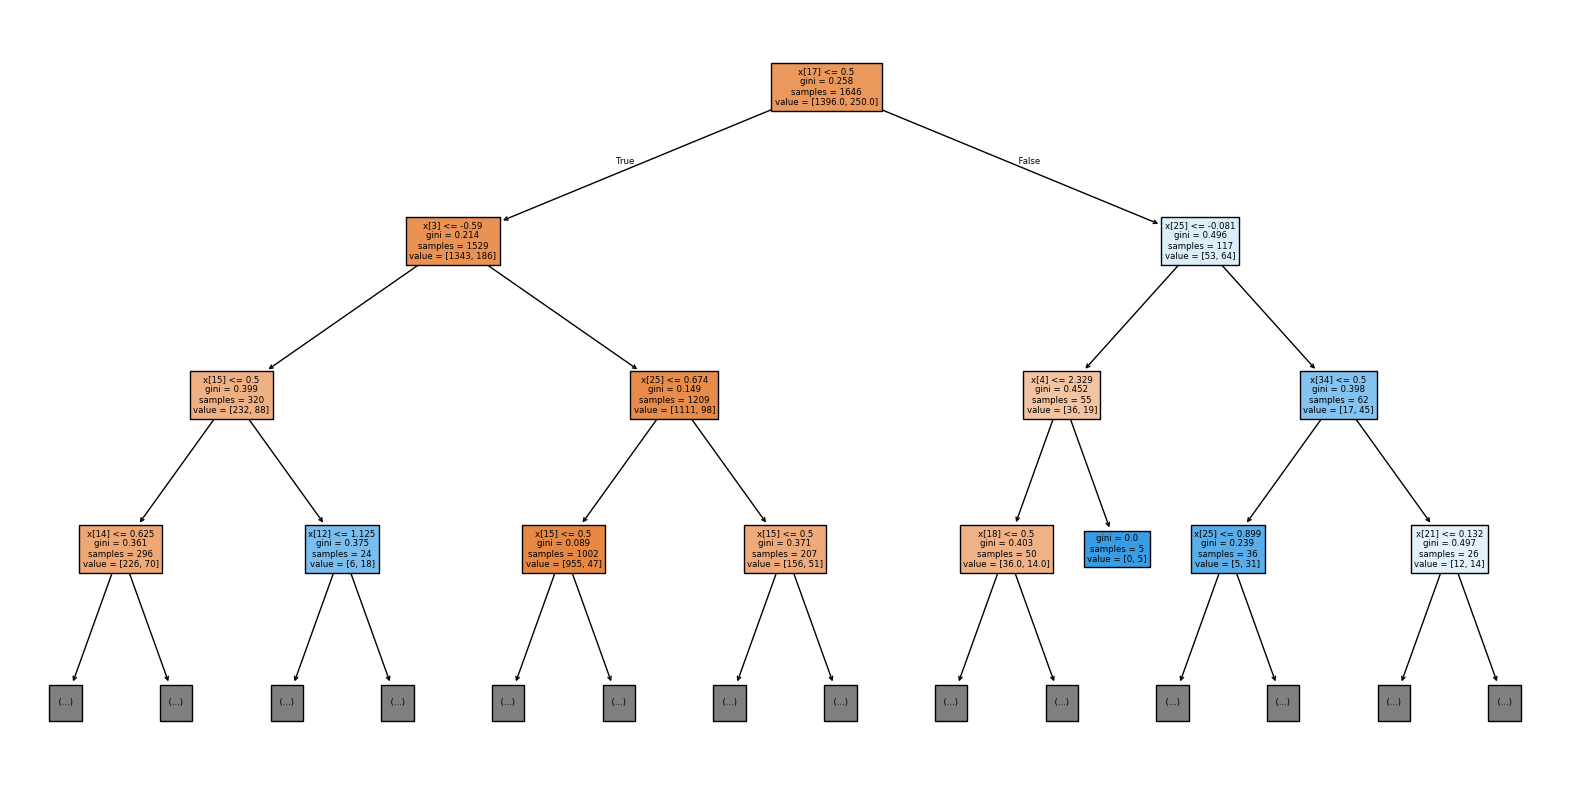

In [235]:
from sklearn import tree
import matplotlib.pyplot as plt

X_train_transformed = preprocessor.fit_transform(X_train)

dt_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

dt_model.fit(
    X_train_transformed,
    y_train
)

plt.figure(figsize=(20,10))

tree.plot_tree(
    dt_model,
    filled=True,
    max_depth=3
)

plt.show()

In [236]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_split=5,
        random_state=42,
        class_weight='balanced'
    ))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

In [237]:
print("Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print(classification_report(
    y_test,
    y_pred_rf
))

Accuracy: 0.8592233009708737
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       349
           1       0.55      0.41      0.47        63

    accuracy                           0.86       412
   macro avg       0.73      0.68      0.70       412
weighted avg       0.85      0.86      0.85       412



In [238]:
rf_model = rf_pipeline.named_steps['model']

feature_names = (
    rf_pipeline.named_steps['preprocessor']
    .get_feature_names_out()
)

import pandas as pd

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    'Importance',
    ascending=False
)

print(importance_df.head(15))

                     Feature  Importance
3               num__Recency    0.120803
25        num__Customer_Days    0.109040
22       num__Total_Spending    0.060544
9          num__MntGoldProds    0.054488
6       num__MntMeatProducts    0.053615
0                num__Income    0.052766
4              num__MntWines    0.048248
17         num__AcceptedCmp5    0.046392
14    num__NumWebVisitsMonth    0.043578
13    num__NumStorePurchases    0.041271
12  num__NumCatalogPurchases    0.039730
15         num__AcceptedCmp3    0.037103
8      num__MntSweetProducts    0.030514
21                  num__Age    0.029004
5             num__MntFruits    0.025601


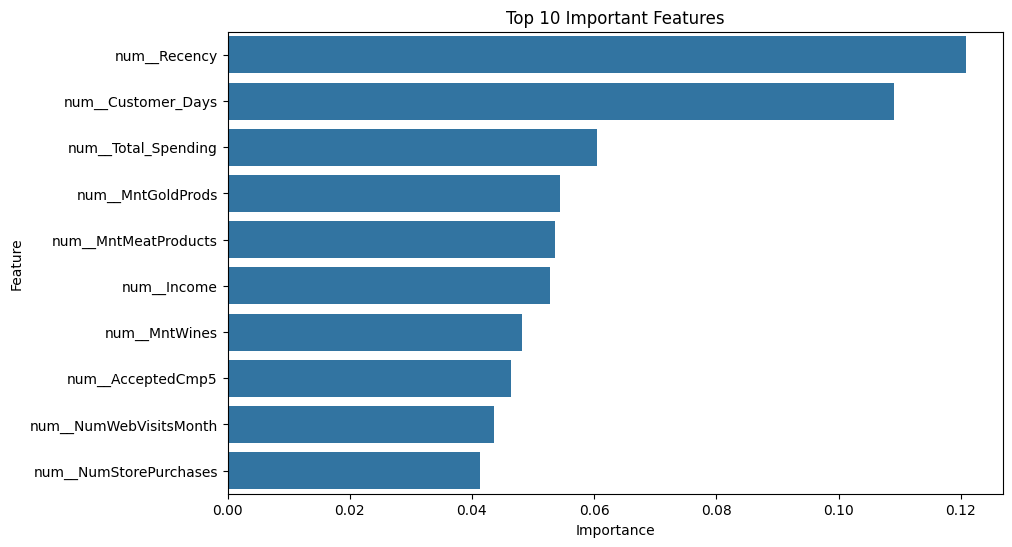

In [239]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Important Features")
plt.show()

In [240]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'model__n_estimators':[100,200,300,500],
    'model__max_depth':[4,6,8,10,None],
    'model__min_samples_split':[2,5,10],
    'model__min_samples_leaf':[1,2,4]
}

random_search = RandomizedSearchCV(
    rf_pipeline,
    param_grid,
    n_iter=20,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train,y_train)

print(random_search.best_params_)

{'model__n_estimators': 200, 'model__min_samples_split': 10, 'model__min_samples_leaf': 4, 'model__max_depth': 6}


In [241]:
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss'
    ))
])

In [242]:
xgb_pipeline.fit(X_train, y_train)

y_pred_xgb = xgb_pipeline.predict(X_test)

In [243]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:",
      accuracy_score(y_test, y_pred_xgb))

print(classification_report(
    y_test,
    y_pred_xgb
))

Accuracy: 0.8810679611650486
              precision    recall  f1-score   support

           0       0.90      0.97      0.93       349
           1       0.69      0.40      0.51        63

    accuracy                           0.88       412
   macro avg       0.80      0.68      0.72       412
weighted avg       0.87      0.88      0.87       412



In [244]:
cluster_features = [
    'Income',
    'Total_Spending',
    'Total_Purchases',
    'Age',
    'Customer_Days'
]

cluster_df = df[cluster_features]

In [245]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cluster_scaled = scaler.fit_transform(cluster_df)

In [246]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42
    )

    kmeans.fit(cluster_scaled)

    inertia.append(kmeans.inertia_)

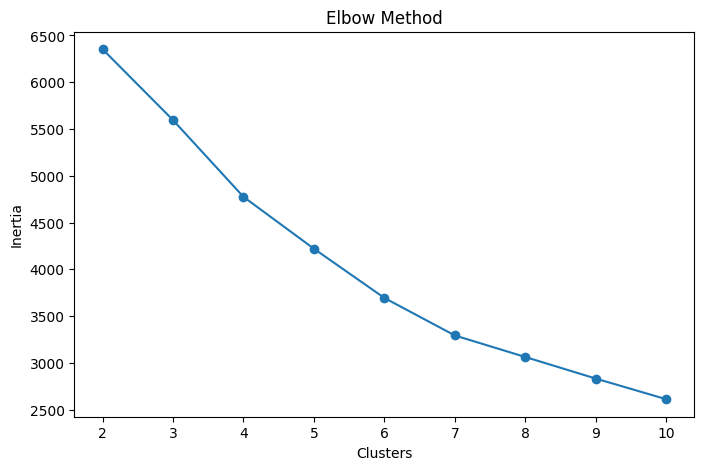

In [247]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    inertia,
    marker='o'
)

plt.xlabel("Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [248]:
from sklearn.metrics import silhouette_score

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42
    )

    labels = kmeans.fit_predict(cluster_scaled)

    score = silhouette_score(
        cluster_scaled,
        labels
    )

    print(
        f"K={k} : {score:.4f}"
    )

K=2 : 0.3589
K=3 : 0.2905
K=4 : 0.2426
K=5 : 0.2437
K=6 : 0.2513
K=7 : 0.2491
K=8 : 0.2358
K=9 : 0.2403
K=10 : 0.2411


In [249]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=2,
    init='k-means++',
    random_state=42
)

df['Cluster'] = kmeans.fit_predict(cluster_scaled)

In [250]:
print(df['Cluster'].value_counts())

Cluster
0    1127
1     931
Name: count, dtype: int64


In [251]:
print(kmeans.cluster_centers_)

[[-0.60060607 -0.76470861 -0.76682026 -0.15961847 -0.12416515]
 [ 0.7299077   0.9293391   0.93190536  0.19398197  0.15089608]]


In [252]:
cluster_profile = df.groupby('Cluster')[
    [
        'Income',
        'Total_Spending',
        'Total_Purchases',
        'Age',
        'Customer_Days'
    ]
].mean().round(2)

cluster_profile

,Income,Total_Spending,Total_Purchases,Age,Customer_Days
Cluster,,,,,
0,37089.50,144.69,7.00,55.31,326.91
1,70815.29,1164.96,19.22,59.52,383.40


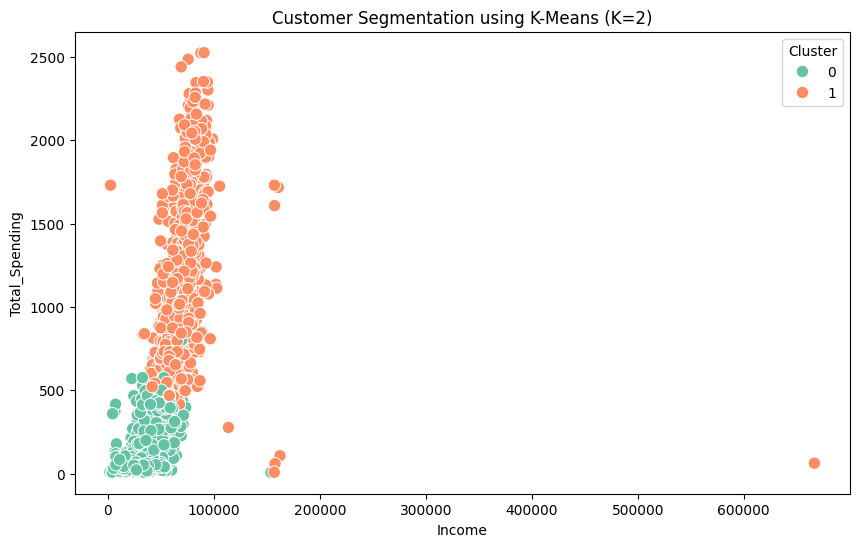

In [253]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Income',
    y='Total_Spending',
    hue='Cluster',
    palette='Set2',
    s=80
)

plt.title('Customer Segmentation using K-Means (K=2)')
plt.show()

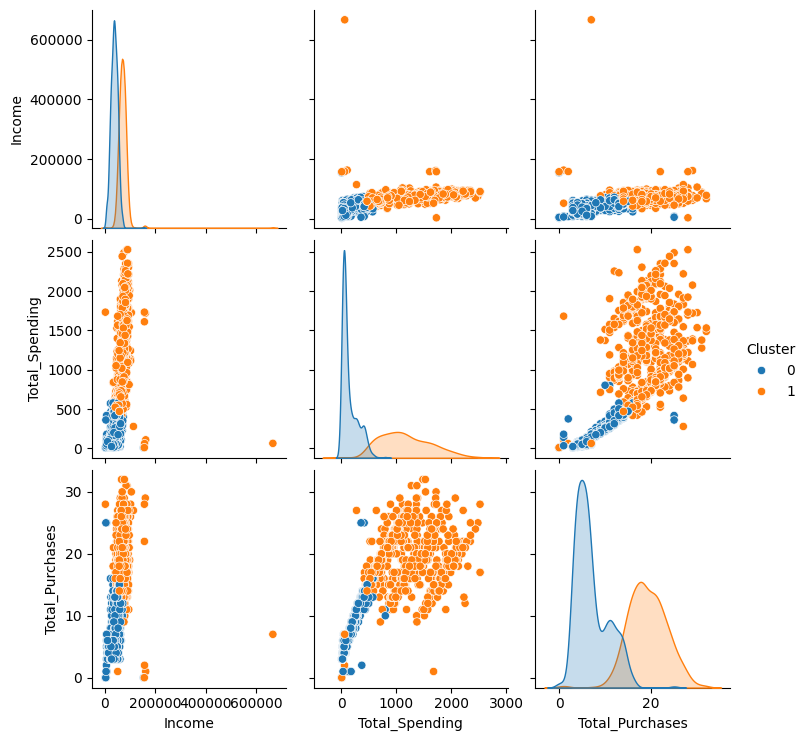

In [254]:
sns.pairplot(
    df,
    vars=[
        'Income',
        'Total_Spending',
        'Total_Purchases'
    ],
    hue='Cluster'
)

plt.show()

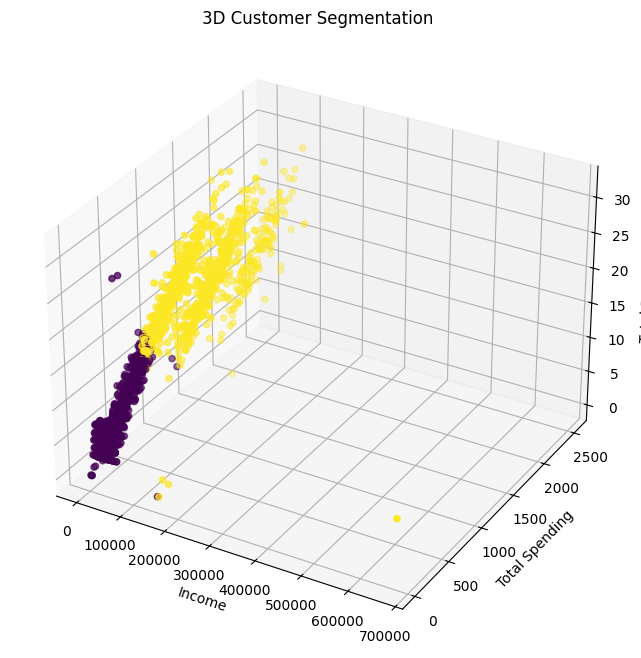

In [255]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df['Income'],
    df['Total_Spending'],
    df['Total_Purchases'],
    c=df['Cluster']
)

ax.set_xlabel('Income')
ax.set_ylabel('Total Spending')
ax.set_zlabel('Total Purchases')

plt.title('3D Customer Segmentation')
plt.show()

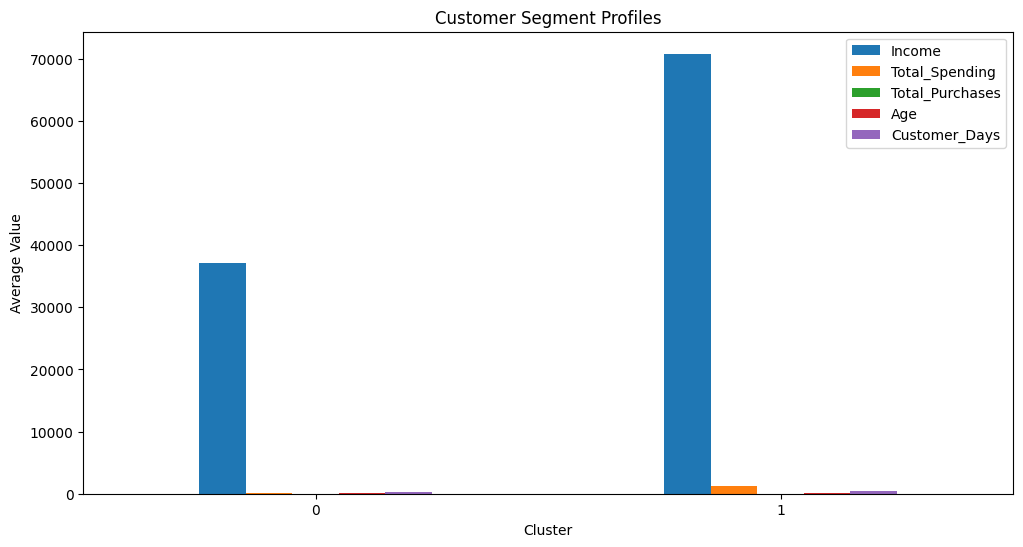

In [256]:
import matplotlib.pyplot as plt

cluster_profile.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Customer Segment Profiles")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.show()

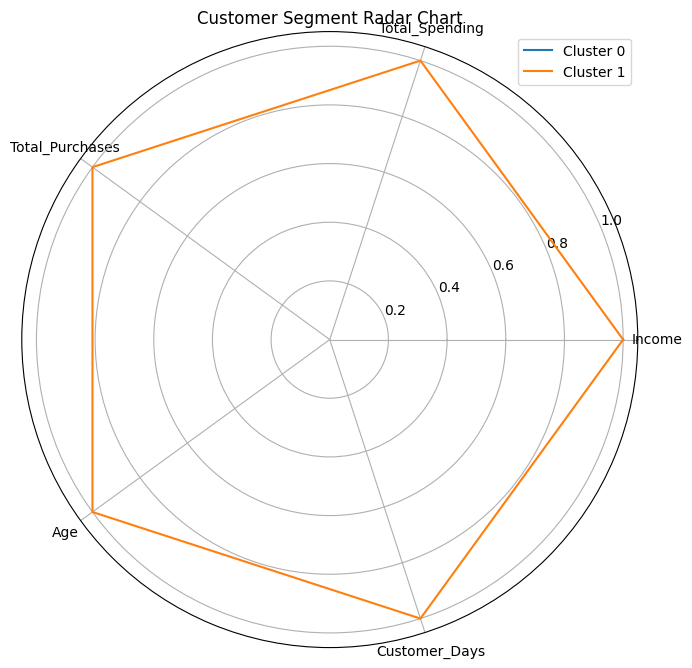

In [257]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

features = [
    'Income',
    'Total_Spending',
    'Total_Purchases',
    'Age',
    'Customer_Days'
]

profile_norm = (
    cluster_profile -
    cluster_profile.min()
) / (
    cluster_profile.max() -
    cluster_profile.min()
)

labels = np.array(features)

angles = np.linspace(
    0,
    2*np.pi,
    len(labels),
    endpoint=False
)

angles = np.concatenate((angles,[angles[0]]))

fig = plt.figure(figsize=(8,8))
ax = plt.subplot(111, polar=True)

for i in range(len(profile_norm)):
    values = profile_norm.iloc[i].tolist()
    values += values[:1]

    ax.plot(
        angles,
        values,
        label=f'Cluster {i}'
    )

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

plt.legend()
plt.title("Customer Segment Radar Chart")
plt.show()

In [258]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.8,
    min_samples=10
)

df['DBSCAN_Cluster'] = dbscan.fit_predict(cluster_scaled)

In [259]:
import numpy as np

n_clusters = len(set(df['DBSCAN_Cluster'])) - (
    1 if -1 in df['DBSCAN_Cluster'].values else 0
)

noise_points = np.sum(df['DBSCAN_Cluster'] == -1)

print("Number of Clusters:", n_clusters)
print("Noise Points:", noise_points)

Number of Clusters: 1
Noise Points: 130


In [260]:
print(df['DBSCAN_Cluster'].value_counts())

DBSCAN_Cluster
 0    1928
-1     130
Name: count, dtype: int64


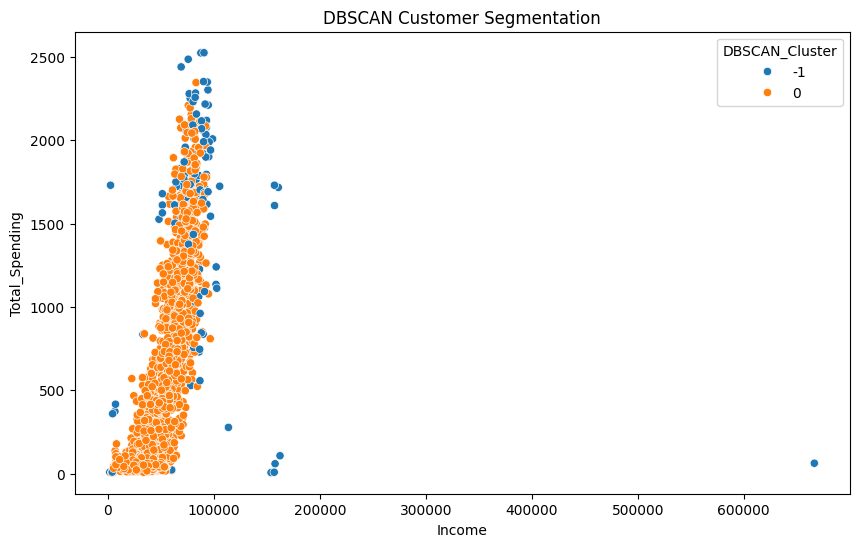

In [261]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Income',
    y='Total_Spending',
    hue='DBSCAN_Cluster',
    palette='tab10'
)

plt.title("DBSCAN Customer Segmentation")
plt.show()

In [262]:
dbscan_profile = df.groupby('DBSCAN_Cluster')[
    [
        'Income',
        'Total_Spending',
        'Total_Purchases',
        'Age',
        'Customer_Days'
    ]
].mean().round(2)

dbscan_profile

,Income,Total_Spending,Total_Purchases,Age,Customer_Days
DBSCAN_Cluster,,,,,
-1,85190.83,1477.11,18.60,55.30,324.44
0,50131.79,547.52,12.12,57.34,354.35


In [263]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

models = {
    "Logistic Regression": y_pred,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb
}

results = []

for model_name, predictions in models.items():
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions)
    })

comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.sort_values(
    by="Accuracy",
    ascending=False
)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
3,XGBoost,0.881068,0.694444,0.396825,0.505051
1,Decision Tree,0.873786,0.689655,0.317460,0.434783
2,Random Forest,0.859223,0.553191,0.412698,0.472727
0,Logistic Regression,0.849515,0.504673,0.857143,0.635294


In [264]:
comparison_df.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1 Score": "{:.4f}"
})

,Model,Accuracy,Precision,Recall,F1 Score
3,XGBoost,0.8811,0.6944,0.3968,0.5051
1,Decision Tree,0.8738,0.6897,0.3175,0.4348
2,Random Forest,0.8592,0.5532,0.4127,0.4727
0,Logistic Regression,0.8495,0.5047,0.8571,0.6353


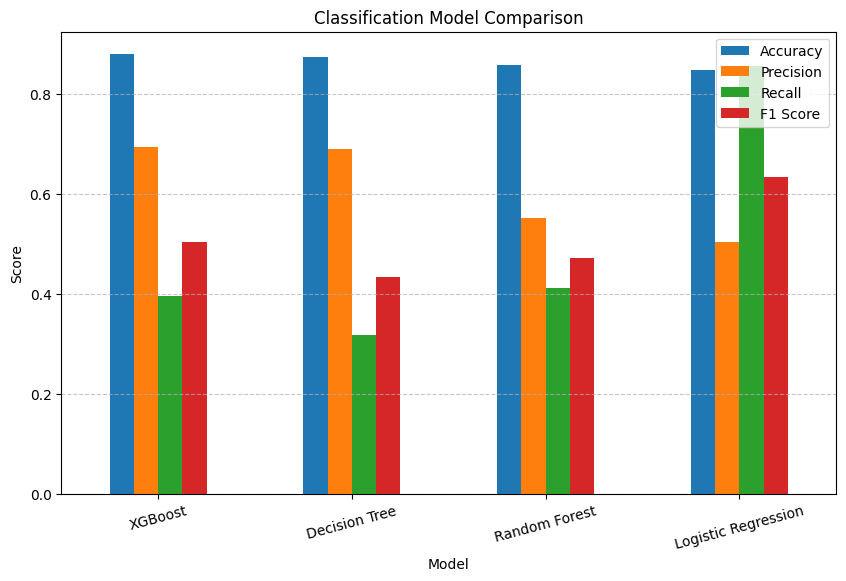

In [265]:
import matplotlib.pyplot as plt

comparison_df.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Classification Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()